29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Test accuracy: 0.8823000192642212
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


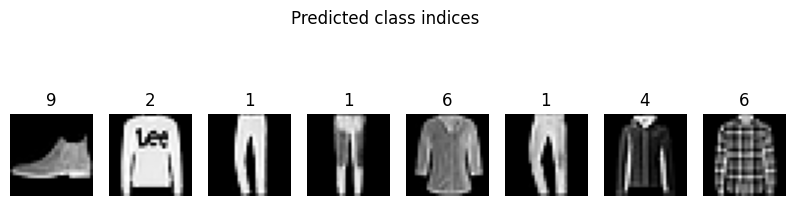

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

# 1) CREATE (flatten > Dense ReLU > Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])



# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices");
plt.show()